<a href="https://colab.research.google.com/github/anshupandey/B7_GAAP_GCP/blob/main/nlp2sql_chinook_gemini_langgraph_secure_approach2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Secure NLP2SQL over Chinook with Google Gemini + LangGraph

This tutorial rewrites **Approach 2** from the attached notebook.

The updated workflow is:

```text
user question + user credentials
        ↓
authenticate user
        ↓
fetch only authorized Chinook tables
        ↓
Gemini selects relevant tables from the authorized table list
        ↓
authorize selected tables again
        ↓
fetch schema only for authorized selected tables
        ↓
Gemini generates SQL using only authorized schema
        ↓
authorize SQL tables again before execution
        ↓
execute SQL
        ↓
Gemini generates final answer
```

The key change is that **authentication and authorization are enforced before every database operation**, including:

1. fetching table names,
2. fetching table schema,
3. executing generated SQL.

This is important for NLP2SQL systems because the LLM must never see or query tables that the authenticated user is not allowed to access.


## Prerequisites

You need:

- Python 3.10+
- A local **Chinook SQLite database**
- A Google Gemini API key
- Basic understanding of SQL, Python functions, and LangGraph state graphs

Install the required packages in the next cell.


In [1]:
# Run this once in your notebook environment.
# If your environment already has these packages, this cell will finish quickly.

%pip install -q pandas sqlglot langgraph google-generativeai


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-exporter-otlp-proto-grpc 1.41.1 requires opentelemetry-exporter-otlp-proto-common==1.41.1, but you have opentelemetry-exporter-otlp-proto-common 1.38.0 which is incompatible.
opentelemetry-exporter-otlp-proto-grpc 1.41.1 requires opentelemetry-proto==1.41.1, but you have opentelemetry-proto 1.38.0 which is incompatible.
opentelemetry-exporter-otlp-proto-grpc 1.41.1 requires opentelemetry-sdk~=1.41.1, but you have opentelemetry-sdk 1.38.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


## 1. Import Libraries and Locate the Existing Chinook Database

This notebook expects the Chinook database to already exist.

The original notebook uses:

```python
sqlite:///datasets/Chinook.db
```

So this tutorial first checks `datasets/Chinook.db`. If your database is somewhere else, update `DB_PATH`.


In [3]:
from __future__ import annotations

import ast
import getpass
import os
import re
import sqlite3
from dataclasses import dataclass
from pathlib import Path
from typing import Any, TypedDict

import pandas as pd
import sqlglot
from sqlglot import exp

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

DB_PATH = Path("../datasets/Chinook.db")

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DB_PATH}. "
        "Place the existing Chinook.db at datasets/Chinook.db, "
        "or update DB_PATH to point to your Chinook SQLite file."
    )

conn = sqlite3.connect(DB_PATH)
print(f"Connected to Chinook database at: {DB_PATH}")


Connected to Chinook database at: ../datasets/Chinook.db


## 2. Define Demo Users, Credentials, and Table Permissions

SQLite does not provide role-based users like PostgreSQL or SQL Server. Therefore, this tutorial demonstrates the pattern using an **application-level security layer**.

In production, replace this section with your real identity provider and entitlement system, such as:

- OAuth / SSO / IAM,
- LDAP / Active Directory,
- database roles,
- policy engines,
- row-level or column-level access controls.

For this tutorial, we define three users:

| User | Password | Permission Level |
|---|---|---|
| `sales_user` | `sales-pass` | Customers, invoices, invoice lines, tracks, albums, artists |
| `hr_user` | `hr-pass` | Employees only |
| `admin_user` | `admin-pass` | All Chinook tables |


In [4]:
def get_all_database_tables(conn: sqlite3.Connection) -> list[str]:
    """Internal helper. Do not expose this directly to the LLM or end user."""
    rows = conn.execute(
        "SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%' ORDER BY name;"
    ).fetchall()
    return [row[0] for row in rows]


ALL_CHINOOK_TABLES = set(get_all_database_tables(conn))
ALL_CHINOOK_TABLES


{'Album',
 'Artist',
 'Customer',
 'Employee',
 'Genre',
 'Invoice',
 'InvoiceLine',
 'MediaType',
 'Playlist',
 'PlaylistTrack',
 'Track'}

In [5]:
USER_DIRECTORY: dict[str, dict[str, Any]] = {
    "sales_user": {
        "password": "sales-pass",
        "allowed_tables": {
            "Customer", "Invoice", "InvoiceLine", "Track", "Album", "Artist", "Genre", "MediaType"
        },
    },
    "hr_user": {
        "password": "hr-pass",
        "allowed_tables": {"Employee"},
    },
    "admin_user": {
        "password": "admin-pass",
        "allowed_tables": ALL_CHINOOK_TABLES,
    },
}


@dataclass(frozen=True)
class UserSession:
    username: str
    allowed_tables: frozenset[str]


class AuthenticationError(Exception):
    pass


class AuthorizationError(Exception):
    pass


def authenticate_user(username: str, password: str) -> UserSession:
    """Authenticate the user and return an immutable user session."""
    user_record = USER_DIRECTORY.get(username)

    if not user_record or password != user_record["password"]:
        raise AuthenticationError("Invalid username or password.")

    return UserSession(
        username=username,
        allowed_tables=frozenset(user_record["allowed_tables"]),
    )


def require_authenticated(session: UserSession | None) -> UserSession:
    """Ensure a valid authenticated session exists."""
    if not isinstance(session, UserSession):
        raise AuthenticationError("A valid authenticated session is required.")
    return session


def require_table_access(session: UserSession, requested_tables: set[str]) -> None:
    """Authorize table access for this user session."""
    unauthorized = requested_tables - set(session.allowed_tables)

    if unauthorized:
        raise AuthorizationError(
            f"User '{session.username}' is not authorized for table(s): {sorted(unauthorized)}"
        )


## 3. Secure Database Access Layer

This is the most important part of the rewritten Approach 2.

Every function below requires a `UserSession` and checks permissions before touching the database.

The LLM does not get the full database schema. It only receives:

1. table names the user is authorized to access,
2. schema for the subset of authorized tables selected for the question.


In [6]:
def secure_list_authorized_tables(
    conn: sqlite3.Connection,
    session: UserSession,
) -> list[str]:
    """Fetch only the table names this authenticated user is authorized to see."""
    session = require_authenticated(session)

    all_tables = set(get_all_database_tables(conn))
    visible_tables = sorted(all_tables & set(session.allowed_tables))

    return visible_tables


def secure_get_table_schema(
    conn: sqlite3.Connection,
    session: UserSession,
    table_names: list[str],
) -> str:
    """Fetch schema only for authorized tables."""
    session = require_authenticated(session)

    requested = set(table_names)
    require_table_access(session, requested)

    schema_blocks = []

    for table_name in table_names:
        # Table names cannot be parameterized in SQLite, so validate against known authorized tables first.
        if table_name not in ALL_CHINOOK_TABLES:
            raise ValueError(f"Unknown table: {table_name}")

        columns = conn.execute(f'PRAGMA table_info("{table_name}")').fetchall()
        foreign_keys = conn.execute(f'PRAGMA foreign_key_list("{table_name}")').fetchall()

        column_lines = [
            f"- {col[1]} {col[2]}{' PRIMARY KEY' if col[5] else ''}"
            for col in columns
        ]

        fk_lines = [
            f"- {fk[3]} references {fk[2]}({fk[4]})"
            for fk in foreign_keys
        ]

        schema = f"Table: {table_name}\nColumns:\n" + "\n".join(column_lines)

        if fk_lines:
            schema += "\nForeign Keys:\n" + "\n".join(fk_lines)

        schema_blocks.append(schema)

    return "\n\n".join(schema_blocks)


def extract_table_names_from_sql(sql: str) -> set[str]:
    """Extract table names referenced by a SQL query using sqlglot."""
    try:
        parsed = sqlglot.parse_one(sql, read="sqlite")
    except Exception as exc:
        raise ValueError(f"Could not parse SQL safely: {exc}") from exc

    return {table.name for table in parsed.find_all(exp.Table)}


def validate_read_only_sql(sql: str) -> None:
    """Only allow single SELECT statements for this tutorial."""
    cleaned = sql.strip().rstrip(";")

    if ";" in cleaned:
        raise AuthorizationError("Only one SQL statement is allowed.")

    try:
        parsed = sqlglot.parse_one(cleaned, read="sqlite")
    except Exception as exc:
        raise AuthorizationError(f"Invalid SQL: {exc}") from exc

    if not isinstance(parsed, exp.Select):
        raise AuthorizationError("Only SELECT queries are allowed.")


def secure_execute_sql(
    conn: sqlite3.Connection,
    session: UserSession,
    sql: str,
) -> pd.DataFrame:
    """Authorize again before SQL execution, then execute the read-only query."""
    session = require_authenticated(session)

    validate_read_only_sql(sql)

    referenced_tables = extract_table_names_from_sql(sql)
    require_table_access(session, referenced_tables)

    return pd.read_sql_query(sql, conn)


In [7]:
# Test authentication and authorized table discovery.

sales_session = authenticate_user("sales_user", "sales-pass")
hr_session = authenticate_user("hr_user", "hr-pass")

print("Sales user authorized tables:")
print(secure_list_authorized_tables(conn, sales_session))

print("\nHR user authorized tables:")
print(secure_list_authorized_tables(conn, hr_session))


Sales user authorized tables:
['Album', 'Artist', 'Customer', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Track']

HR user authorized tables:
['Employee']


## 4. Gemini Prompt Helpers

The prompts below are intentionally strict:

- Gemini must select tables only from the authorized table list.
- Gemini must generate only SQLite `SELECT` queries.
- Gemini must not use tables outside the supplied schema.
- The application still validates the output after Gemini responds.

This means the security model does **not** rely only on prompt instructions. The secure database layer remains the final enforcement point.


In [32]:
def parse_python_list(text: str) -> list[str]:
    """Parse Gemini output expected as a Python list of strings."""
    cleaned = text.strip()

    # Sometimes LLMs wrap output in markdown fences.
    cleaned = re.sub(r"^```(?:python)?", "", cleaned).strip()
    cleaned = re.sub(r"```$", "", cleaned).strip()

    value = ast.literal_eval(cleaned)

    if not isinstance(value, list) or not all(isinstance(item, str) for item in value):
        raise ValueError(f"Expected a Python list of strings, got: {text}")

    return value


def clean_sql(text: str) -> str:
    """Remove markdown fences and normalize generated SQL."""
    cleaned = text.strip()
    cleaned = re.sub(r"^```(?:sql)?", "", cleaned).strip()
    cleaned = re.sub(r"```$", "", cleaned).strip()
    return cleaned.rstrip(";") + ";"


from langchain.chat_models import init_chat_model
def call_gemini(prompt,temperature=0):
    model = init_chat_model("google_genai:gemini-2.5-flash",temperature=temperature)
    response = model.invoke(prompt)
    return response.text


def select_relevant_tables_with_gemini(
    question: str,
    authorized_tables: list[str],
) -> list[str]:
    prompt = f"""
You are helping build a secure NLP2SQL system.

User question:
{question}

The authenticated user is authorized to see only these tables:
{authorized_tables}

Task:
Select only the tables needed to answer the question.

Rules:
- Choose only from the authorized table list.
- Do not invent table names.
- Preserve exact table name casing.
- Return only a Python list of strings.
- No markdown.
- No explanation.

Example:
['Customer', 'Invoice']
"""

    response_text = call_gemini(prompt)
    selected_tables = parse_python_list(response_text)

    unknown = set(selected_tables) - set(authorized_tables)
    if unknown:
        raise AuthorizationError(
            f"Gemini selected table(s) outside the authorized list: {sorted(unknown)}"
        )

    return selected_tables


def generate_sql_with_gemini(
    question: str,
    authorized_schema: str,
    dialect: str = "SQLite",
    top_k: int = 10,
) -> str:
    prompt = f"""
You are a careful SQL generator.

Database dialect:
{dialect}

Authorized database schema:
{authorized_schema}

User question:
{question}

Task:
Write a SQL query to answer the user question.

Rules:
- Use only the tables and columns shown in the authorized schema.
- Return only the SQL query.
- No markdown.
- No explanation.
- Generate only one SELECT statement.
- Do not generate INSERT, UPDATE, DELETE, DROP, ALTER, CREATE, PRAGMA, or ATTACH statements.
- Limit results to {top_k} rows unless the question asks for an aggregate count or total.
"""

    response_text = call_gemini(prompt)
    return clean_sql(response_text)


def generate_final_answer_with_gemini(
    question: str,
    sql: str,
    result_df: pd.DataFrame,
) -> str:
    result_markdown = result_df.to_markdown(index=False)

    prompt = f"""
Answer the user question using only the SQL result.

User question:
{question}

SQL query:
{sql}

SQL result:
{result_markdown}

Rules:
- Provide a concise business-friendly answer.
- Do not mention unauthorized tables or hidden schema.
- If the result is empty, say that no matching records were found.

Final answer:
"""

    return call_gemini(prompt, temperature=0.2)


## 5. Define LangGraph State

The graph state carries the user question, user credentials, authenticated session, authorized metadata, generated SQL, query result, and final answer.

In a real application, avoid storing raw passwords in graph state. Use an already-authenticated session token or identity context instead. Here, raw credentials are used only to make the tutorial easy to run.


In [33]:
class SecureNLP2SQLState(TypedDict, total=False):
    question: str

    # Demo credentials. In production, replace with a token/session from your auth layer.
    username: str
    password: str

    # Security context.
    session: UserSession
    authorized_tables: list[str]

    # LLM-selected metadata.
    selected_tables: list[str]
    selected_schema: str

    # SQL and result.
    query: str
    result_df: pd.DataFrame
    answer: str


## 6. Build Secure LangGraph Nodes

Each node has a narrow responsibility.

The authorization checks happen in:

- `fetch_authorized_tables`
- `fetch_authorized_schema`
- `execute_authorized_query`

This is the central difference from a basic NLP2SQL chain.


In [34]:
def authenticate_node(state: SecureNLP2SQLState) -> dict[str, Any]:
    session = authenticate_user(state["username"], state["password"])
    return {"session": session}


def fetch_authorized_tables_node(state: SecureNLP2SQLState) -> dict[str, Any]:
    session = require_authenticated(state["session"])
    authorized_tables = secure_list_authorized_tables(conn, session)
    return {"authorized_tables": authorized_tables}


def select_tables_node(state: SecureNLP2SQLState) -> dict[str, Any]:
    selected_tables = select_relevant_tables_with_gemini(
        question=state["question"],
        authorized_tables=state["authorized_tables"],
    )
    return {"selected_tables": selected_tables}


def fetch_authorized_schema_node(state: SecureNLP2SQLState) -> dict[str, Any]:
    session = require_authenticated(state["session"])

    # Authorization is re-checked here before schema is fetched.
    schema = secure_get_table_schema(
        conn=conn,
        session=session,
        table_names=state["selected_tables"],
    )

    return {"selected_schema": schema}


def generate_sql_node(state: SecureNLP2SQLState) -> dict[str, Any]:
    sql = generate_sql_with_gemini(
        question=state["question"],
        authorized_schema=state["selected_schema"],
    )

    return {"query": sql}


def execute_authorized_query_node(state: SecureNLP2SQLState) -> dict[str, Any]:
    session = require_authenticated(state["session"])

    # Authorization is re-checked here against the actual generated SQL.
    result_df = secure_execute_sql(
        conn=conn,
        session=session,
        sql=state["query"],
    )

    return {"result_df": result_df}


def final_answer_node(state: SecureNLP2SQLState) -> dict[str, Any]:
    answer = generate_final_answer_with_gemini(
        question=state["question"],
        sql=state["query"],
        result_df=state["result_df"],
    )

    return {"answer": answer}


## 7. Compile the LangGraph Workflow

The graph follows the rewritten secure Approach 2 sequence.


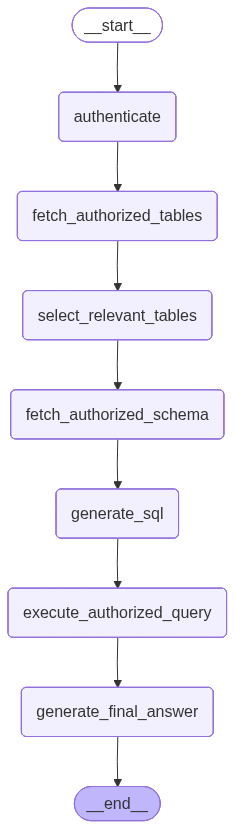

In [35]:
from langgraph.graph import START, StateGraph

graph_builder = StateGraph(SecureNLP2SQLState)

graph_builder.add_node("authenticate", authenticate_node)
graph_builder.add_node("fetch_authorized_tables", fetch_authorized_tables_node)
graph_builder.add_node("select_relevant_tables", select_tables_node)
graph_builder.add_node("fetch_authorized_schema", fetch_authorized_schema_node)
graph_builder.add_node("generate_sql", generate_sql_node)
graph_builder.add_node("execute_authorized_query", execute_authorized_query_node)
graph_builder.add_node("generate_final_answer", final_answer_node)

graph_builder.add_edge(START, "authenticate")
graph_builder.add_edge("authenticate", "fetch_authorized_tables")
graph_builder.add_edge("fetch_authorized_tables", "select_relevant_tables")
graph_builder.add_edge("select_relevant_tables", "fetch_authorized_schema")
graph_builder.add_edge("fetch_authorized_schema", "generate_sql")
graph_builder.add_edge("generate_sql", "execute_authorized_query")
graph_builder.add_edge("execute_authorized_query", "generate_final_answer")

secure_graph = graph_builder.compile()
secure_graph


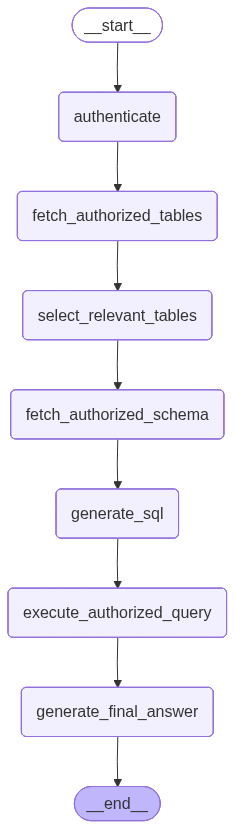

In [36]:
# Optional graph visualization.
# This may require extra dependencies in some notebook environments.

from IPython.display import Image, display

try:
    display(Image(secure_graph.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Graph visualization skipped:", exc)


## 8. Example 1 — Authorized Sales Question

The `sales_user` is allowed to access customer and invoice tables, so the workflow can answer a revenue/customer question.


In [37]:
sales_input = {
    "username": "sales_user",
    "password": "sales-pass",
    "question": "Who are the top spending customers?",
}

sales_output = secure_graph.invoke(sales_input)

print("Authorized tables:")
print(sales_output["authorized_tables"])

print("\nSelected tables:")
print(sales_output["selected_tables"])

print("\nGenerated SQL:")
print(sales_output["query"])

print("\nSQL result:")
display(sales_output["result_df"])

print("\nFinal answer:")
print(sales_output["answer"])


Authorized tables:
['Album', 'Artist', 'Customer', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Track']

Selected tables:
['Customer', 'Invoice']

Generated SQL:
SELECT
  C.FirstName,
  C.LastName,
  SUM(I.Total) AS TotalSpending
FROM Customer AS C
JOIN Invoice AS I
  ON C.CustomerId = I.CustomerId
GROUP BY
  C.CustomerId,
  C.FirstName,
  C.LastName
ORDER BY
  TotalSpending DESC
LIMIT 10;

SQL result:


,FirstName,LastName,TotalSpending
0,Helena,Holý,49.62
1,Richard,Cunningham,47.62
2,Luis,Rojas,46.62
3,Ladislav,Kovács,45.62
4,Hugh,O'Reilly,45.62
5,Frank,Ralston,43.62
6,Julia,Barnett,43.62
7,Fynn,Zimmermann,43.62
8,Astrid,Gruber,42.62
9,Victor,Stevens,42.62



Final answer:
The top spending customers are:
*   Helena Holý with $49.62
*   Richard Cunningham with $47.62
*   Luis Rojas with $46.62
*   Ladislav Kovács with $45.62
*   Hugh O'Reilly with $45.62
*   Frank Ralston with $43.62
*   Julia Barnett with $43.62
*   Fynn Zimmermann with $43.62
*   Astrid Gruber with $42.62
*   Victor Stevens with $42.62


## 9. Example 2 — Authorized HR Question

The `hr_user` can access only the `Employee` table. An employee-count question should work.


In [38]:
hr_input = {
    "username": "hr_user",
    "password": "hr-pass",
    "question": "How many employees are there?",
}

hr_output = secure_graph.invoke(hr_input)

print("Authorized tables:")
print(hr_output["authorized_tables"])

print("\nSelected tables:")
print(hr_output["selected_tables"])

print("\nGenerated SQL:")
print(hr_output["query"])

print("\nSQL result:")
display(hr_output["result_df"])

print("\nFinal answer:")
print(hr_output["answer"])


Authorized tables:
['Employee']

Selected tables:
['Employee']

Generated SQL:
SELECT COUNT(*) FROM Employee;

SQL result:


,COUNT(*)
0,8



Final answer:
There are 8 employees.


## 10. Example 3 — Authorization Failure

Now ask `hr_user` a sales/customer question.

The HR user is not authorized for `Customer` or `Invoice`.

The workflow should fail safely before unauthorized schema or query execution is allowed.


In [39]:
try:
    blocked_output = secure_graph.invoke({
        "username": "hr_user",
        "password": "hr-pass",
        "question": "Who are the top spending customers?",
    })
    print(blocked_output["answer"])
except Exception as exc:
    print(type(exc).__name__)
    print(exc)


AuthorizationError
User 'hr_user' is not authorized for table(s): ['customers', 'order_items', 'orders']


## 11. Direct Security Test — SQL Execution Is Also Protected

Even if a generated or manually supplied SQL query tries to access an unauthorized table, the execution wrapper blocks it.

This matters because the LLM output should never be trusted blindly.


In [40]:
try:
    secure_execute_sql(
        conn=conn,
        session=hr_session,
        sql="SELECT * FROM Customer LIMIT 5;",
    )
except Exception as exc:
    print(type(exc).__name__)
    print(exc)


AuthorizationError
User 'hr_user' is not authorized for table(s): ['Customer']


## 12. Production Notes

For production, strengthen this tutorial pattern with the following controls:

1. **Use real authentication**
   - Replace the demo password dictionary with SSO, OAuth, IAM, LDAP, or database-native authentication.

2. **Avoid raw passwords in graph state**
   - Pass a signed session token or request identity context instead.

3. **Use database-native authorization where possible**
   - Application-level authorization is useful, but database roles and row-level security are stronger.

4. **Validate generated SQL**
   - Keep the `SELECT`-only rule.
   - Block multi-statement SQL.
   - Parse referenced tables and columns.
   - Consider approval gates for high-risk data.

5. **Limit schema exposure**
   - Never give the LLM full database schema unless the user is authorized for all of it.

6. **Log security decisions**
   - Log user identity, selected tables, generated SQL, authorization decisions, and execution timestamp.

7. **Consider row-level and column-level policies**
   - Table-level access is the minimum. Real systems often require masking PII and limiting rows by region, department, customer segment, or role.


## Short Exercise

Modify the notebook to add a new user called `music_user`.

The user should have access only to:

- `Artist`
- `Album`
- `Track`
- `Genre`
- `MediaType`

Then test these two questions:

1. **Allowed question**  
   `Which artists have the most tracks?`

2. **Blocked question**  
   `Who are the top spending customers?`

Expected behavior:

- The first question should run because it uses music catalog tables.
- The second question should be blocked because `music_user` should not access `Customer` or `Invoice`.


In [41]:
# Exercise starter code

USER_DIRECTORY["music_user"] = {
    "password": "music-pass",
    "allowed_tables": {"Artist", "Album", "Track", "Genre", "MediaType"},
}

music_session = authenticate_user("music_user", "music-pass")
print("Music user authorized tables:")
print(secure_list_authorized_tables(conn, music_session))

# TODO 1:
# Run secure_graph.invoke(...) for:
# "Which artists have the most tracks?"

# TODO 2:
# Run secure_graph.invoke(...) for:
# "Who are the top spending customers?"
# Confirm that unauthorized access is blocked.


Music user authorized tables:
['Album', 'Artist', 'Genre', 'MediaType', 'Track']


## Summary

This rewritten notebook implements Approach 2 using:

- the existing Chinook database,
- Google Gemini API for table selection, SQL generation, and answer generation,
- LangGraph for workflow orchestration,
- user authentication before the workflow starts,
- table authorization before table discovery, schema retrieval, and SQL execution,
- SQL parsing and read-only validation before executing generated SQL.

The central principle is:

> The LLM can suggest SQL, but the application must authenticate, authorize, validate, and enforce access before any database operation.
